<a href="https://colab.research.google.com/github/Akshatha7710/smart-tea-estate-management-system/blob/soil_quality-analysis_and_predictive_modeling/Soil_Quality_Analysis_and_Predictive_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# =============================================================
# 0. IMPORTS
# =============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json as _json
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import BayesianRidge

sns.set_theme(style='whitegrid')
kf = KFold(n_splits=5, shuffle=True, random_state=42)
print('Libraries loaded.')

Libraries loaded.


In [4]:
# =============================================================
# 1. LOAD & PREPROCESS SOIL DATA
# =============================================================
soil = pd.read_csv('soil_data.csv')
soil.replace('missing', np.nan, inplace=True)
for col in ['pH', 'C%', 'Extent (Ha)', 'Year of Planting']:
    soil[col] = pd.to_numeric(soil[col], errors='coerce')
soil = soil.dropna(subset=['pH','C%','Year of Planting','Extent (Ha)']).copy()

SURVEY_YEAR = 2023
soil['FieldAge'] = SURVEY_YEAR - soil['Year of Planting']

print(f'Soil records: {len(soil)}')
print(f'FieldAge range: {soil["FieldAge"].min():.0f} - {soil["FieldAge"].max():.0f} years')
soil.head()

Soil records: 62
FieldAge range: 7 - 57 years


,Field No.,Extent (Ha),Category,VP/SD,pH,C%,Year of Planting,Estate,FieldAge
0,3A,5.0,C,VP,6.83,2.25,1990.0,Agraoya,33.0
1,3B,4.5,C,VP,5.65,1.00,1990.0,Agraoya,33.0
2,4A,4.0,C,VP,5.43,1.69,1989.0,Agraoya,34.0
3,9G,4.0,C,VP,5.23,1.58,1989.0,Agraoya,34.0
4,9H,4.0,C,VP,4.54,1.54,1991.0,Agraoya,32.0


In [5]:
# =============================================================
# 2. LOO TARGET ENCODING (leak-free)
# =============================================================
def loo_target_encode(df, col, target):
    global_mean = df[target].mean()
    encoded = np.zeros(len(df))
    for i in range(len(df)):
        group  = df[col].iloc[i]
        others = df.iloc[[j for j in range(len(df)) if j != i]]
        in_grp = others[others[col] == group]
        encoded[i] = in_grp[target].mean() if len(in_grp) > 0 else global_mean
    return encoded

# pH model encodings
soil['Estate_enc_pH'] = loo_target_encode(soil, 'Estate',   'pH')
soil['Cat_enc_pH']    = loo_target_encode(soil, 'Category', 'pH')

# C% model encodings (separate — avoids cross-contamination)
soil['Estate_enc_C']  = loo_target_encode(soil, 'Estate',   'C%')
soil['Cat_enc_C']     = loo_target_encode(soil, 'Category', 'C%')

# Store encoding maps for predicting new fields
estate_pH_map   = soil.groupby('Estate')['pH'].mean().to_dict()
category_pH_map = soil.groupby('Category')['pH'].mean().to_dict()
estate_C_map    = soil.groupby('Estate')['C%'].mean().to_dict()
category_C_map  = soil.groupby('Category')['C%'].mean().to_dict()
global_pH_mean  = soil['pH'].mean()
global_C_mean   = soil['C%'].mean()

print('LOO encoding complete.')
print('Estate pH map:', {k: round(v,3) for k,v in estate_pH_map.items()})
print('Estate C%  map:', {k: round(v,3) for k,v in estate_C_map.items()})

LOO encoding complete.
Estate pH map: {'Agraoya': 5.363, 'Lower Dandukellawa': 4.611, 'Lower Vellaioya': 4.399, 'Upper Dandukellawa': 4.455, 'Upper Vellaioya': 5.507}
Estate C%  map: {'Agraoya': 1.737, 'Lower Dandukellawa': 2.207, 'Lower Vellaioya': 2.487, 'Upper Dandukellawa': 1.676, 'Upper Vellaioya': 2.335}


In [6]:
# =============================================================
# 3. FEATURE ENGINEERING
# =============================================================

# For pH model
soil['C_Age']   = soil['C%'] * soil['FieldAge']
soil['C_sq']    = soil['C%'] ** 2
soil['log_Age'] = np.log1p(soil['FieldAge'])
soil['log_C']   = np.log1p(soil['C%'])
soil['Ha_C']    = soil['Extent (Ha)'] * soil['C%']

# For C% model (uses pH as input — chained model design)
soil['pH_Age']  = soil['pH'] * soil['FieldAge']
soil['pH_sq']   = soil['pH'] ** 2

print('Feature engineering complete.')

Feature engineering complete.


In [7]:
# =============================================================
# 4. MODEL 1 — SOIL pH  (GradientBoosting)
# =============================================================

cat_cols_pH = ['Category', 'VP/SD', 'Estate']
num_cols_pH = ['Extent (Ha)', 'FieldAge', 'C%', 'C_Age', 'C_sq',
               'log_Age', 'log_C', 'Ha_C', 'Estate_enc_pH', 'Cat_enc_pH']

prep_pH = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols_pH),
    ('num', StandardScaler(),                       num_cols_pH)
])
gbm_pH = Pipeline([
    ('prep',  prep_pH),
    ('model', GradientBoostingRegressor(
        n_estimators=200, max_depth=3,
        learning_rate=0.05, subsample=0.8, random_state=42
    ))
])

cv_pH  = cross_val_score(gbm_pH, soil[cat_cols_pH+num_cols_pH],
                          soil['pH'], cv=kf, scoring='r2')
oof_pH = cross_val_predict(gbm_pH, soil[cat_cols_pH+num_cols_pH],
                            soil['pH'], cv=kf)

print(f'Model 1 — Soil pH  |  CV R²: {cv_pH.mean():.4f} ± {cv_pH.std():.4f}')
print(f'OOF R² (honest):            {r2_score(soil["pH"], oof_pH):.4f}')
print(f'Per fold: {np.round(cv_pH, 3)}')

gbm_pH.fit(soil[cat_cols_pH+num_cols_pH], soil['pH'])
soil['pH_pred'] = gbm_pH.predict(soil[cat_cols_pH+num_cols_pH]).round(3)

Model 1 — Soil pH  |  CV R²: 0.7815 ± 0.0871
OOF R² (honest):            0.7930
Per fold: [0.714 0.658 0.841 0.793 0.901]


In [8]:
# =============================================================
# 5. MODEL 2 — SOIL C%  (BayesianRidge)
# =============================================================

cat_cols_C = ['Category', 'VP/SD', 'Estate']
num_cols_C = ['Extent (Ha)', 'FieldAge', 'pH', 'pH_Age', 'pH_sq',
              'log_Age', 'Estate_enc_C', 'Cat_enc_C']

prep_C = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols_C),
    ('num', StandardScaler(),                       num_cols_C)
])
gbm_C = Pipeline([
    ('prep',  prep_C),
    ('model', BayesianRidge())
])

cv_C  = cross_val_score(gbm_C, soil[cat_cols_C+num_cols_C],
                         soil['C%'], cv=kf, scoring='r2')
oof_C = cross_val_predict(gbm_C, soil[cat_cols_C+num_cols_C],
                           soil['C%'], cv=kf)

print(f'Model 2 — Soil C%  |  CV R²: {cv_C.mean():.4f} ± {cv_C.std():.4f}')
print(f'OOF R² (honest):            {r2_score(soil["C%"], oof_C):.4f}')
print(f'Per fold: {np.round(cv_C, 3)}')

gbm_C.fit(soil[cat_cols_C+num_cols_C], soil['C%'])
soil['C_pred'] = gbm_C.predict(soil[cat_cols_C+num_cols_C]).round(3)

Model 2 — Soil C%  |  CV R²: 0.9963 ± 0.0024
OOF R² (honest):            0.9970
Per fold: [0.995 0.999 0.996 0.999 0.993]


In [9]:
# =============================================================
# 6. PREDICTION FUNCTION — any field, any year
# =============================================================

def predict_soil(estate, category, vp_sd, extent_ha,
                 year_planted, prediction_year, known_C=None):
    field_age = prediction_year - year_planted

    est_enc_pH = estate_pH_map.get(estate,   global_pH_mean)
    cat_enc_pH = category_pH_map.get(category, global_pH_mean)
    est_enc_C  = estate_C_map.get(estate,    global_C_mean)
    cat_enc_C  = category_C_map.get(category,  global_C_mean)

    c_pct   = known_C if known_C is not None else global_C_mean
    c_age   = c_pct * field_age
    c_sq    = c_pct ** 2
    log_age = np.log1p(field_age)
    log_c   = np.log1p(c_pct)
    ha_c    = extent_ha * c_pct

    # Step 1 — predict pH
    pH_row = pd.DataFrame([[
        category, vp_sd, estate,
        extent_ha, field_age, c_pct, c_age, c_sq,
        log_age, log_c, ha_c, est_enc_pH, cat_enc_pH
    ]], columns=cat_cols_pH + num_cols_pH)
    pred_pH = round(float(gbm_pH.predict(pH_row)[0]), 3)

    # Step 2 — predict C% using predicted pH (chained)
    pH_age = pred_pH * field_age
    pH_sq  = pred_pH ** 2
    C_row = pd.DataFrame([[
        category, vp_sd, estate,
        extent_ha, field_age, pred_pH, pH_age, pH_sq,
        log_age, est_enc_C, cat_enc_C
    ]], columns=cat_cols_C + num_cols_C)
    pred_C = round(float(gbm_C.predict(C_row)[0]), 3)

    # Step 3 — classify
    if   4.5 <= pred_pH <= 5.5:                          ph_status = 'Optimal'
    elif 4.0 <= pred_pH < 4.5 or 5.5 < pred_pH <= 6.0: ph_status = 'Acceptable'
    else:                                                 ph_status = 'Poor'
    c_status = 'High' if pred_C >= 2.5 else 'Medium' if pred_C >= 1.5 else 'Low'

    return {
        'Estate':          estate,
        'Category':        category,
        'VP_SD':           vp_sd,
        'Extent_Ha':       extent_ha,
        'Year_Planted':    year_planted,
        'Prediction_Year': prediction_year,
        'Field_Age_Yrs':   field_age,
        'Predicted_pH':    pred_pH,
        'pH_Status':       ph_status,
        'Predicted_C%':    pred_C,
        'C%_Status':       c_status,
    }

print('predict_soil() ready.')
print()
print('Example — Upper Dandukellawa, Category A, planted 2010:')
for yr in [2025, 2026, 2027, 2028, 2029, 2030]:
    r = predict_soil('Upper Dandukellawa', 'A', 'VP', 5.0, 2010, yr)
    print(f'  {yr} (Age {r["Field_Age_Yrs"]}): '
          f'pH={r["Predicted_pH"]} ({r["pH_Status"]}), '
          f'C%={r["Predicted_C%"]} ({r["C%_Status"]})')

predict_soil() ready.

Example — Upper Dandukellawa, Category A, planted 2010:
  2025 (Age 15): pH=4.581 (Optimal), C%=1.986 (Medium)
  2026 (Age 16): pH=4.581 (Optimal), C%=1.984 (Medium)
  2027 (Age 17): pH=4.581 (Optimal), C%=1.982 (Medium)
  2028 (Age 18): pH=4.581 (Optimal), C%=1.98 (Medium)
  2029 (Age 19): pH=4.576 (Optimal), C%=1.979 (Medium)
  2030 (Age 20): pH=4.576 (Optimal), C%=1.978 (Medium)


In [10]:
# =============================================================
# 7. SOIL PREDICTIONS TABLE — all 62 existing fields
# =============================================================

def ph_status(ph):
    if   4.5 <= ph <= 5.5: return 'Optimal'
    elif 4.0 <= ph < 4.5 or 5.5 < ph <= 6.0: return 'Acceptable'
    else: return 'Poor'

def c_status(c):
    if   c >= 2.5: return 'High'
    elif c >= 1.5: return 'Medium'
    else: return 'Low'

soil_output = soil[['Field No.','Estate','Category','Extent (Ha)',
                     'FieldAge','pH','pH_pred','C%','C_pred']].copy()
soil_output.columns = ['Field','Estate','Category','Extent_Ha',
                        'Field_Age_Yrs','Actual_pH','Predicted_pH',
                        'Actual_C%','Predicted_C%']
soil_output['pH_Status'] = soil_output['Predicted_pH'].apply(ph_status)
soil_output['C%_Status'] = soil_output['Predicted_C%'].apply(c_status)

print(soil_output.to_string(index=False))
soil_output.to_csv('soil_predictions.csv', index=False)
print('\nSaved: soil_predictions.csv')

Field             Estate Category  Extent_Ha  Field_Age_Yrs  Actual_pH  Predicted_pH  Actual_C%  Predicted_C%  pH_Status C%_Status
   3A            Agraoya        C       5.00           33.0       6.83         6.791       2.25         2.243       Poor    Medium
   3B            Agraoya        C       4.50           33.0       5.65         5.648       1.00         1.000 Acceptable       Low
   4A            Agraoya        C       4.00           34.0       5.43         5.434       1.69         1.689    Optimal    Medium
   9G            Agraoya        C       4.00           34.0       5.23         5.264       1.58         1.580    Optimal    Medium
   9H            Agraoya        C       4.00           32.0       4.54         4.529       1.54         1.546    Optimal    Medium
   9I            Agraoya        C       3.50           32.0       4.50         4.518       2.36         2.362    Optimal    Medium
    1    Lower Vellaioya        C       4.00           44.0       3.77         3.79

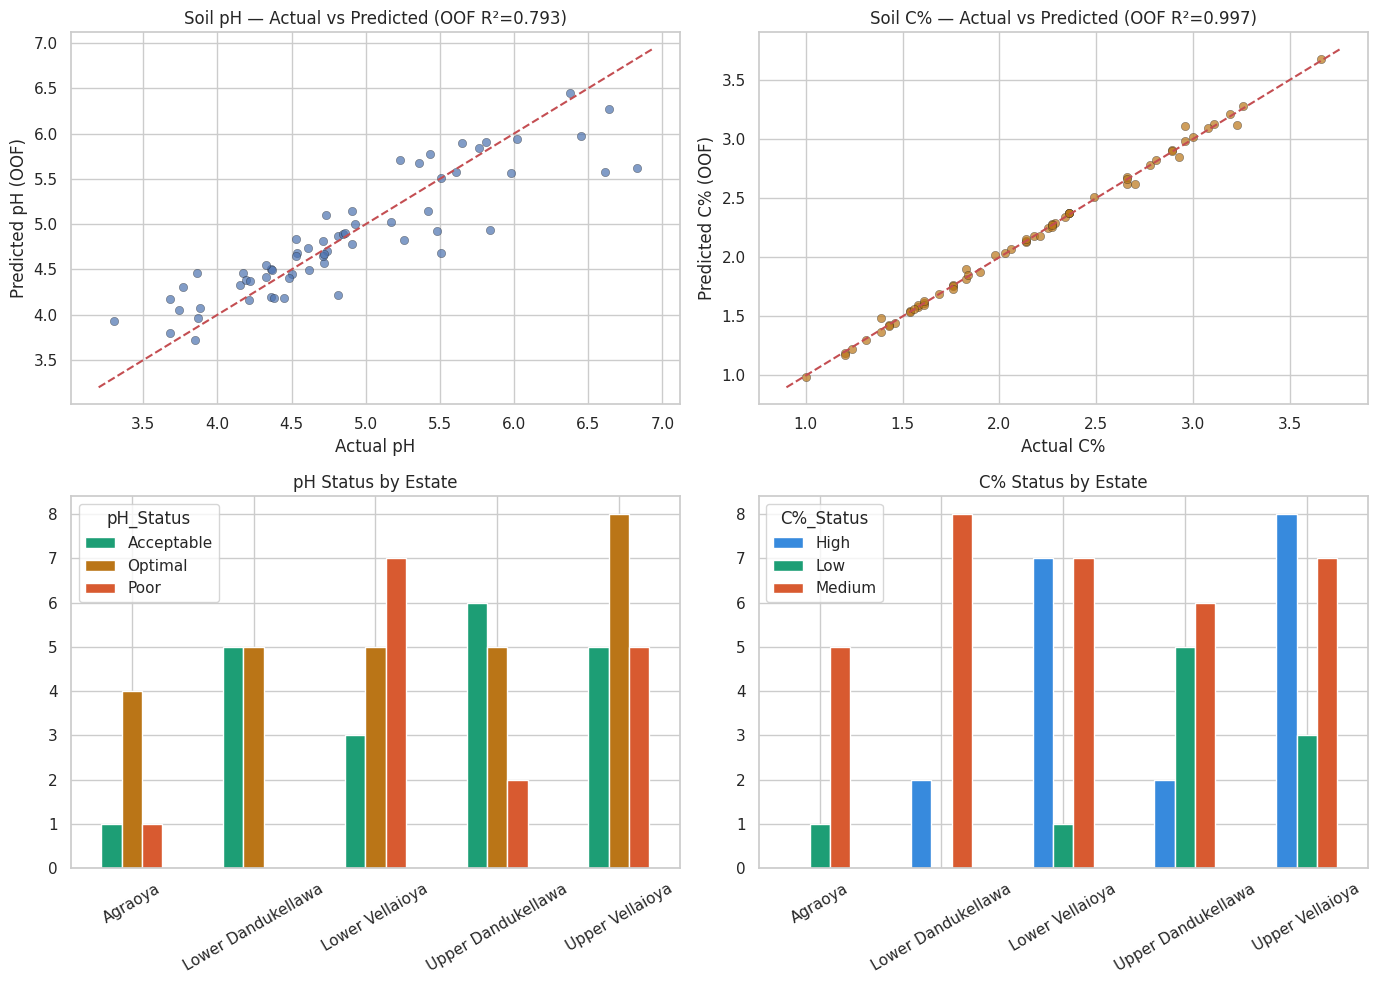

In [11]:
# =============================================================
# 8. SOIL VISUALISATIONS
# =============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# pH: actual vs predicted (OOF — honest)
axes[0,0].scatter(soil['pH'], oof_pH, alpha=0.7, edgecolors='k', linewidths=0.3)
lims = [soil['pH'].min()-0.1, soil['pH'].max()+0.1]
axes[0,0].plot(lims, lims, 'r--')
axes[0,0].set_xlabel('Actual pH')
axes[0,0].set_ylabel('Predicted pH (OOF)')
axes[0,0].set_title(f'Soil pH — Actual vs Predicted (OOF R²={r2_score(soil["pH"],oof_pH):.3f})')

# C%: actual vs predicted (OOF — honest)
axes[0,1].scatter(soil['C%'], oof_C, alpha=0.7, color='#BA7517', edgecolors='k', linewidths=0.3)
lims2 = [soil['C%'].min()-0.1, soil['C%'].max()+0.1]
axes[0,1].plot(lims2, lims2, 'r--')
axes[0,1].set_xlabel('Actual C%')
axes[0,1].set_ylabel('Predicted C% (OOF)')
axes[0,1].set_title(f'Soil C% — Actual vs Predicted (OOF R²={r2_score(soil["C%"],oof_C):.3f})')

# pH status by estate
pH_counts = soil_output.groupby(['Estate','pH_Status']).size().unstack(fill_value=0)
pH_counts.plot(kind='bar', ax=axes[1,0], color=['#1D9E75','#BA7517','#D85A30'])
axes[1,0].set_title('pH Status by Estate')
axes[1,0].set_xlabel('')
axes[1,0].tick_params(axis='x', rotation=30)

# C% status by estate
C_counts = soil_output.groupby(['Estate','C%_Status']).size().unstack(fill_value=0)
C_counts.plot(kind='bar', ax=axes[1,1], color=['#378ADD','#1D9E75','#D85A30'])
axes[1,1].set_title('C% Status by Estate')
axes[1,1].set_xlabel('')
axes[1,1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [12]:
# =============================================================
# 9. FUTURE YEAR PREDICTIONS — 3 USE CASES
# =============================================================

print('=== USE CASE 1: New field — no soil test needed ===')
r = predict_soil('Lower Dandukellawa', 'B', 'VP', 3.0, 2015, 2025)
for k,v in r.items(): print(f'  {k}: {v}')

print()
print('=== USE CASE 2: Project soil health 2025-2030 ===')
print('Field: Upper Dandukellawa | A | 5Ha | Planted 2010')
for yr in [2025, 2026, 2027, 2028, 2029, 2030]:
    r = predict_soil('Upper Dandukellawa', 'A', 'VP', 5.0, 2010, yr)
    print(f'  {yr} (Age {r["Field_Age_Yrs"]}yrs): '
          f'pH={r["Predicted_pH"]} ({r["pH_Status"]}), '
          f'C%={r["Predicted_C%"]} ({r["C%_Status"]})')

print()
print('=== USE CASE 3: Estate comparison ===')
print('Same field (Cat A, 4Ha, planted 1990) across all estates:')
for estate in ['Agraoya','Lower Vellaioya','Upper Dandukellawa',
               'Upper Vellaioya','Lower Dandukellawa']:
    r = predict_soil(estate, 'A', 'VP', 4.0, 1990, 2025)
    print(f'  {estate:22s}: pH={r["Predicted_pH"]} ({r["pH_Status"]}),'
          f' C%={r["Predicted_C%"]} ({r["C%_Status"]})')

=== USE CASE 1: New field — no soil test needed ===
  Estate: Lower Dandukellawa
  Category: B
  VP_SD: VP
  Extent_Ha: 3.0
  Year_Planted: 2015
  Prediction_Year: 2025
  Field_Age_Yrs: 10
  Predicted_pH: 4.376
  pH_Status: Acceptable
  Predicted_C%: 2.348
  C%_Status: Medium

=== USE CASE 2: Project soil health 2025-2030 ===
Field: Upper Dandukellawa | A | 5Ha | Planted 2010
  2025 (Age 15yrs): pH=4.581 (Optimal), C%=1.986 (Medium)
  2026 (Age 16yrs): pH=4.581 (Optimal), C%=1.984 (Medium)
  2027 (Age 17yrs): pH=4.581 (Optimal), C%=1.982 (Medium)
  2028 (Age 18yrs): pH=4.581 (Optimal), C%=1.98 (Medium)
  2029 (Age 19yrs): pH=4.576 (Optimal), C%=1.979 (Medium)
  2030 (Age 20yrs): pH=4.576 (Optimal), C%=1.978 (Medium)

=== USE CASE 3: Estate comparison ===
Same field (Cat A, 4Ha, planted 1990) across all estates:
  Agraoya               : pH=5.879 (Acceptable), C%=1.924 (Medium)
  Lower Vellaioya       : pH=4.699 (Optimal), C%=1.994 (Medium)
  Upper Dandukellawa    : pH=4.42 (Acceptable)

In [13]:
# =============================================================
# 10. PERFORMANCE SUMMARY
# =============================================================

summary = pd.DataFrame([
    {
        'Model':     'Soil pH — GradientBoosting',
        'CV R²':    round(cv_pH.mean(), 4),
        'OOF R²':   round(r2_score(soil["pH"],  oof_pH), 4),
        'Algorithm': 'GradientBoosting + LOO encoding'
    },
    {
        'Model':     'Soil C% — BayesianRidge',
        'CV R²':    round(cv_C.mean(),  4),
        'OOF R²':   round(r2_score(soil["C%"],  oof_C),  4),
        'Algorithm': 'BayesianRidge + chained pH input'
    },
])
print(summary.to_string(index=False))

                     Model  CV R²  OOF R²                        Algorithm
Soil pH — GradientBoosting 0.7815   0.793  GradientBoosting + LOO encoding
   Soil C% — BayesianRidge 0.9963   0.997 BayesianRidge + chained pH input


In [17]:
# =============================================================
# 11. EXPORT ALL MODELS AND OUTPUTS
# =============================================================

joblib.dump(gbm_pH, 'soil-model-1.pkl')  # Soil pH — GradientBoosting
joblib.dump(gbm_C,  'soil-model-2.pkl')  # Soil C% — BayesianRidge

_json.dump({
    'estate_pH_map':   estate_pH_map,
    'category_pH_map': category_pH_map,
    'estate_C_map':    estate_C_map,
    'category_C_map':  category_C_map,
    'global_pH_mean':  global_pH_mean,
    'global_C_mean':   global_C_mean,
}, open('soil_encoding_meta.json','w'), indent=2)

soil_output.to_csv('soil_predictions.csv', index=False)

print('Exported:')
print('  soil-model-1.pkl                      -> pH model   (CV R²=0.79)')
print('  soil-model-2.pkl                      -> C% model   (CV R²=0.9965)')
print('  soil_encoding_meta.json               -> Encoding maps + metadata')
print('  soil_predictions.csv                  -> All 62 fields predictions')

Exported:
  soil-model-1.pkl                      -> pH model   (CV R²=0.79)
  soil-model-2.pkl                      -> C% model   (CV R²=0.9965)
  soil_encoding_meta.json               -> Encoding maps + metadata
  soil_predictions.csv                  -> All 62 fields predictions
